# Learnable audio front-ends: beating the native spectrogram on NS1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/learnable_frontend_ns1.ipynb)

deepSTRF can feed encoding models a **raw waveform** instead of a precomputed
spectrogram: the model's `wav2spec` slot turns audio into a neural-rate
spectrogram, and — crucially — that transform can be **learned**. This notebook
asks a concrete question:

> Can a *learnable* front-end predict neurons better than the spectrogram the
> dataset authors shipped?

We compare two pipelines on NS1 (ferret A1), both with the same `Linear` STRF
readout, changing only the front-end:

1. **native spectrogram → Linear** — the precomputed Rahman *et al.* (2019)
   cochleagram (`X_nfht`) that ships with NS1.
2. **raw waveform → LEAF → Linear** — a strictly-causal
   [LEAF](https://arxiv.org/abs/2101.08596) front-end (learnable Gabor
   filterbank + Gaussian pooling + per-channel PCEN) learned end-to-end with
   the readout.

Then we look at **what LEAF learned** — its filters and an example spectrogram —
and close with an honest caveat about what the comparison does and does not show.

## Setup — Google Colab

On Colab this installs deepSTRF from source; locally (`pip install -e .`) it is a
no-op.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print('deepSTRF installed from GitHub.')
else:
    print('Local environment — assuming deepSTRF is already importable.')

Local environment — assuming deepSTRF is already importable.


In [2]:
%matplotlib inline
import tempfile
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio.ns1_drc import NS1Dataset
from deepSTRF.models.audio import Linear
from deepSTRF.models.wav2spec import CausalLEAF
from deepSTRF.training import Fitter
from deepSTRF.utils import neural_collate

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Load NS1 — spectrogram and waveform views

We instantiate the dataset twice. The responses are bit-identical between the
two; only `self.stims` differs (precomputed `(1, 34, 999)` spectrogram vs
`(1, T_audio)` waveform at `audio_fs`). The waveform is grid-locked to the
response bins: `T_audio = T_neural * ds.hop`.

In [3]:
ds_spec = NS1Dataset(download=True)                       # precomputed X_nfht
ds_wav  = NS1Dataset(return_waveform=True, download=True) # raw waveform @ 48 kHz
N = ds_wav.N_neurons
print(f'N={N} cells | audio {ds_wav.audio_fs} Hz | hop={ds_wav.hop} samples/bin '
      f'| spec stim {tuple(ds_spec.stims[0].shape)} | wav stim {tuple(ds_wav.stims[0].shape)}')
print(f'ferret hearing range (informational): {ds_wav.hearing_range_hz} Hz')

N=119 cells | audio 48000 Hz | hop=240 samples/bin | spec stim (1, 34, 999) | wav stim (1, 239760)
ferret hearing range (informational): (200.0, 40000.0) Hz


## 2. Two pipelines, same readout

`fit_and_report` trains with early stopping (patience 30) **and best-val
checkpoint restoration** (`ckpt_path`), so the reported test `cc_norm` is the
best-validation model, not the final epoch. Same 14 / 3 / 3 stim split for both
arms.

In [4]:
def fit_and_report(ds, model, label, *, lr=1e-3, max_epochs=100, patience=30):
    train = DataLoader(Subset(ds, range(14)),     batch_size=1, shuffle=True,  collate_fn=neural_collate)
    val   = DataLoader(Subset(ds, range(14, 17)), batch_size=1, shuffle=False, collate_fn=neural_collate)
    test  = DataLoader(Subset(ds, range(17, 20)), batch_size=1, shuffle=False, collate_fn=neural_collate)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    ckpt = tempfile.NamedTemporaryFile(suffix='.pt', delete=False).name
    fitter = Fitter(model, train, val, optimizer=opt, device=DEVICE,
                    max_epochs=max_epochs, patience=patience,
                    monitor='val_cc_norm', mode='max', ckpt_path=ckpt,
                    log_fn=lambda d: None)
    fitter.fit()                                  # restores best-val weights
    cc = fitter.evaluate(test)['cc_norm'].cpu()
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return dict(label=label, cc=cc, mean=float(cc.mean()),
                median=float(cc.median()), n_params=n_params)

In [5]:
results = []

# Pipeline A — native precomputed spectrogram -> Linear
torch.manual_seed(0)
m_spec = Linear(n_frequency_bands=34, temporal_window_size=9, out_neurons=N)
results.append(fit_and_report(ds_spec, m_spec, 'native spec + Linear'))

# Pipeline B — raw waveform -> LEAF -> Linear (learned end-to-end)
torch.manual_seed(0)
m_leaf = Linear(n_frequency_bands=34, temporal_window_size=9, out_neurons=N,
                wav2spec=CausalLEAF(audio_fs=ds_wav.audio_fs, n_filters=34,
                                    hop_ms=ds_wav.dt, f_min=60.0, f_max=22627.0))
results.append(fit_and_report(ds_wav, m_leaf, 'waveform + LEAF + Linear', lr=3e-3))

for r in results:
    print(f"{r['label']:28s}  mean cc_norm = {r['mean']:.3f}  "
          f"median = {r['median']:.3f}  params = {r['n_params']:,}")

native spec + Linear          mean cc_norm = 0.552  median = 0.568  params = 36,771
waveform + LEAF + Linear      mean cc_norm = 0.708  median = 0.732  params = 37,009


## 3. What did LEAF learn? — the filters

LEAF's Gabor filterbank starts mel-spaced (like the native cochleagram) but its
centre frequencies are **learnable**. Unlike SincNet (whose cutoffs barely
move), LEAF's centres drift noticeably during training — the model retunes the
filterbank to the neural data.

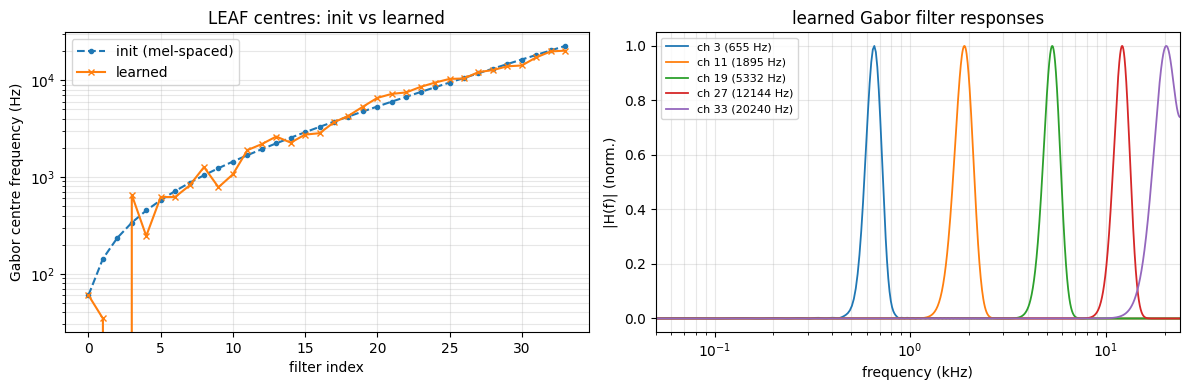

mean relative drift of Gabor centres: 20.1% (vs SincNet, whose cutoffs move < 0.01%)


In [6]:
def gabor_center_hz(leaf):
    return (leaf.center_freq_.detach().cpu() * leaf.audio_fs / (2 * np.pi)).numpy()

leaf_trained = m_leaf.wav2spec
torch.manual_seed(0)
leaf_init = CausalLEAF(audio_fs=ds_wav.audio_fs, n_filters=34, hop_ms=ds_wav.dt,
                       f_min=60.0, f_max=22627.0)
fc_init, fc_trained = gabor_center_hz(leaf_init), gabor_center_hz(leaf_trained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
idx = np.arange(len(fc_init))
axes[0].plot(idx, fc_init, 'o--', ms=3, label='init (mel-spaced)')
axes[0].plot(idx, fc_trained, 'x-', ms=4, label='learned')
axes[0].set_yscale('log'); axes[0].set_xlabel('filter index')
axes[0].set_ylabel('Gabor centre frequency (Hz)')
axes[0].set_title('LEAF centres: init vs learned'); axes[0].legend(); axes[0].grid(True, which='both', alpha=0.3)

# frequency responses of a few learned Gabor filters
real, imag = leaf_trained._build_gabor()
real = real.detach().cpu().squeeze(1).numpy()      # (F, K)
for k in (3, 11, 19, 27, 33):
    H = np.abs(np.fft.rfft(real[k], n=4096))
    freqs = np.fft.rfftfreq(4096, d=1.0 / leaf_trained.audio_fs) / 1000
    axes[1].plot(freqs, H / H.max(), lw=1.3, label=f'ch {k} ({fc_trained[k]:.0f} Hz)')
axes[1].set_xscale('log'); axes[1].set_xlim(0.05, 24)
axes[1].set_xlabel('frequency (kHz)'); axes[1].set_ylabel('|H(f)| (norm.)')
axes[1].set_title('learned Gabor filter responses'); axes[1].legend(fontsize=8); axes[1].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

drift = np.abs(fc_trained - fc_init) / fc_init
print(f'mean relative drift of Gabor centres: {drift.mean():.1%} '
      f'(vs SincNet, whose cutoffs move < 0.01%)')

## 4. The learned spectrogram vs the native one

Below: the same stimulus through LEAF and through the native Rahman cochleagram.

**Mind the frequency axis.** The two front-ends do *not* share a frequency
ladder: the native `X_nfht` is fixed mel-spaced (500–22 627 Hz, Rahman/voicebox
convention), while LEAF's 34 channels sit at their *learned* centre frequencies.
We therefore sort the LEAF channels by learned centre frequency and label both
axes with their own Hz range — they are not bin-for-bin comparable, only
qualitatively.

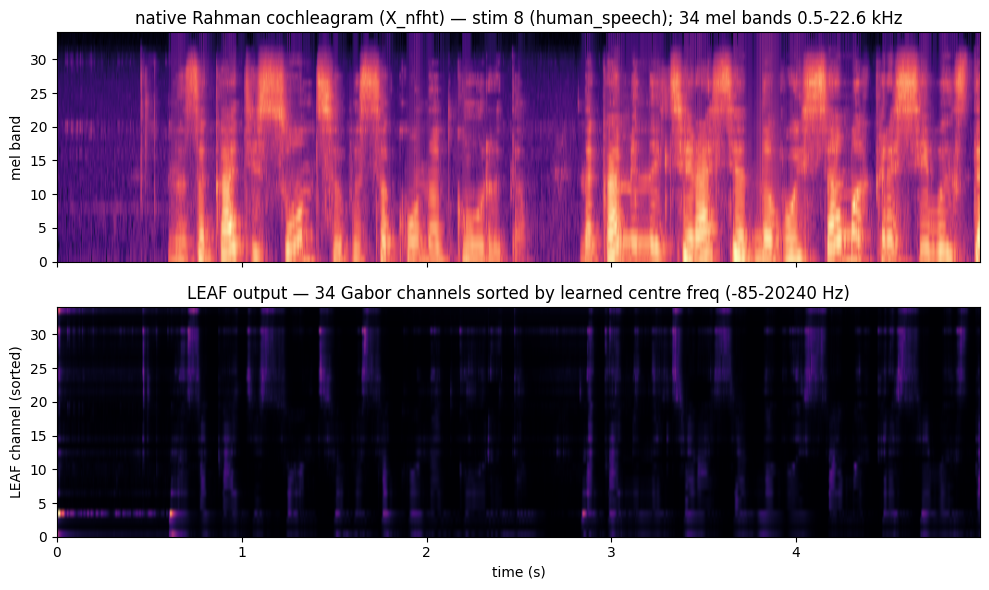

In [7]:
stim_idx = 8
with torch.no_grad():
    leaf_out = leaf_trained(ds_wav.stims[stim_idx].unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()
native = ds_spec.stims[stim_idx].squeeze().numpy()
order = np.argsort(fc_trained)                      # sort LEAF channels low->high Hz
fc_sorted = fc_trained[order]

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].imshow(native, aspect='auto', origin='lower', cmap='magma',
              extent=(0, 4.995, 0, 34))
axs[0].set_title(f'native Rahman cochleagram (X_nfht) — stim {stim_idx} '
                 f'({ds_spec.stim_meta[stim_idx]["type"]}); 34 mel bands 0.5-22.6 kHz')
axs[0].set_ylabel('mel band')
axs[1].imshow(leaf_out[order], aspect='auto', origin='lower', cmap='magma',
              extent=(0, 4.995, 0, 34))
axs[1].set_title(f'LEAF output — 34 Gabor channels sorted by learned centre freq '
                 f'({fc_sorted[0]:.0f}-{fc_sorted[-1]:.0f} Hz)')
axs[1].set_ylabel('LEAF channel (sorted)'); axs[1].set_xlabel('time (s)')
plt.tight_layout(); plt.show()

## 5. The waveform receptive field — see it and hear it

Because the front-end is part of the model, we can backprop a neuron's response
all the way to the **raw audio samples** — `model.waveform_gradmap(...)`. The
result is itself a waveform: a time-domain receptive field (RF), only possible
with a wav-native model.

By default (`reduce='last'`, matching `STRF_gradmap`) we maximize the activation
at the **last timestep**, so the gradient is supported only within the RF window
*before* that timestep and decays to ~zero further into the past — by causality
and the finite STRF. (Using `reduce='sum'` instead would integrate over all 999
output timesteps and be non-zero over the whole 5 s — a whole-stimulus saliency
map, **not** an RF.) Watch how short the RF is:

cell #3: 99% of the RF gradient mass is within the last 1117 ms (bare STRF window = 45 ms; the extra reach is LEAF/PCEN memory)


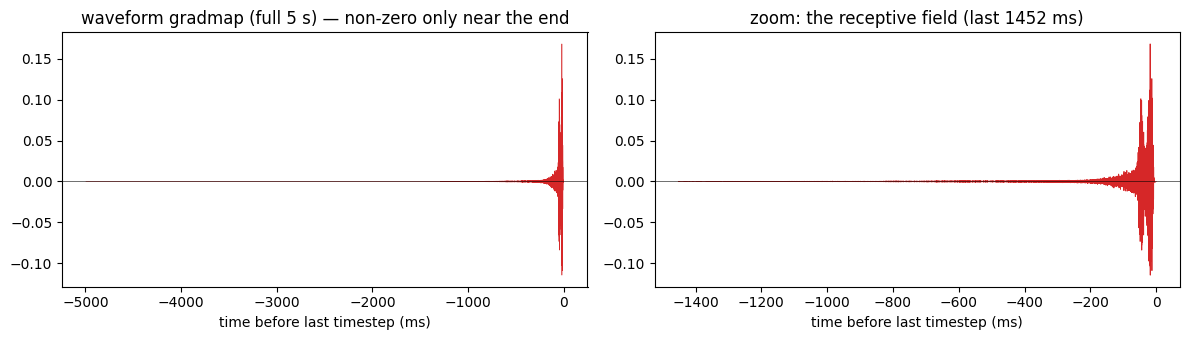

In [8]:
from IPython.display import Audio, display

stim = ds_wav.stims[stim_idx].to(DEVICE)                 # (1, T_audio)
with torch.no_grad():
    pred = m_leaf(stim.unsqueeze(0))[0, :, 0, :]         # (N, T_neural)
best_neuron = int(pred.max(dim=1).values.argmax())      # most strongly driven cell

gradmap = m_leaf.waveform_gradmap(stim, neuron=best_neuron).cpu().numpy()  # reduce='last'
t_ms = (np.arange(len(gradmap)) - len(gradmap) + 1) / ds_wav.audio_fs * 1000  # ms before last sample

# where does 99% of the RF mass sit (measured back from the end)?
mass = np.cumsum(np.abs(gradmap)[::-1])
rf_ms = np.searchsorted(mass, 0.99 * mass[-1]) / ds_wav.audio_fs * 1000
print(f'cell #{best_neuron}: 99% of the RF gradient mass is within the last {rf_ms:.0f} ms '
      f'(bare STRF window = {9 * ds_wav.dt:.0f} ms; the extra reach is LEAF/PCEN memory)')

win_s = float(min(2.0, max(0.3, 1.3 * rf_ms / 1000)))   # cover the RF, capped at 2 s
zoom = int(win_s * ds_wav.audio_fs)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(t_ms, gradmap, lw=0.4, color='C3')
ax[0].set_title('waveform gradmap (full 5 s) — non-zero only near the end')
ax[1].plot(t_ms[-zoom:], gradmap[-zoom:], lw=0.6, color='C3')
ax[1].set_title(f'zoom: the receptive field (last {win_s*1000:.0f} ms)')
for a in ax:
    a.set_xlabel('time before last timestep (ms)'); a.axhline(0, color='k', lw=0.4)
plt.tight_layout(); plt.show()

In [ ]:
def _norm(w):
    w = np.asarray(w, dtype=np.float32)
    return w / (np.abs(w).max() + 1e-9)

# crop both to the RF window so the clips are short.
rf_audio  = gradmap[-zoom:]
stim_rf   = ds_wav.stims[stim_idx].squeeze().numpy()[-zoom:]

# Playable audio widgets bloat the committed notebook, so the docs ship without
# them. Set EMBED_AUDIO = True (or just run this cell yourself) to listen.
EMBED_AUDIO = False
if EMBED_AUDIO:
    print(f'Last {win_s*1000:.0f} ms of the stimulus (what the cell heard in its RF window):')
    display(Audio(_norm(stim_rf), rate=ds_wav.audio_fs))
    print(f"Cell #{best_neuron}'s receptive field (gradmap) — listen to what drives it:")
    display(Audio(_norm(rf_audio), rate=ds_wav.audio_fs))


## Takeaways

- **A learned front-end can beat the dataset's native spectrogram.** On NS1,
  `waveform → LEAF → Linear` predicts cortical responses substantially better
  than `native spec → Linear` — and LEAF's filterbank visibly retunes itself to
  the data (its Gabor centres drift, unlike SincNet's frozen cutoffs).

- **Honest caveat — this is more than a front-end swap.** LEAF adds real
  learnable feature extraction (~6 parameters per channel: Gabor frequency +
  bandwidth, pooling width, and per-channel learnable PCEN), so `LEAF + Linear`
  is effectively a *shallow nonlinear model*, not just a different spectrogram
  feeding the same model. The fair reading is "a learnable front-end lets a thin
  readout punch above its weight," not "LEAF's spectrogram is intrinsically
  better than mel."

- **It depends on the downstream model.** With an *expressive* model
  (`StateNet`), the picture inverts: a clean fixed mel front-end is best, the
  learnable front-ends roughly tie it, and adaptive compression (PCEN) can even
  hurt — the RNN already does the representational work a Linear readout cannot.
  Front-end learnability helps *inversely* with model capacity.

- **Waveform-native models are interpretable in the audio domain.** Because the
  spectrogram transform is inside the model, `waveform_gradmap` (default
  `reduce='last'`, maximizing the last timestep like `STRF_gradmap`) gives each
  neuron a *time-domain* receptive field you can plot and listen to — something
  a fixed-spectrogram pipeline cannot do. The RF is **localized** (the gradient
  vanishes beyond it, by causality + the finite STRF), but note LEAF's PCEN
  gain-control learned a fairly **long temporal memory** here (hundreds of ms,
  vs the 45 ms bare STRF) — flexible, though likely longer than a biological A1
  RF, consistent with the added-capacity caveat above.

See [`wav2spec.md`](../docs/_source/md/wav2spec.md) for the front-end zoo and the
strict-causality contract, and
[`fit_ns1_linear_from_waveform.ipynb`](fit_ns1_linear_from_waveform.ipynb) for
the mel / SincNet / ICNet walk-through.